## Importações

In [1]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import pandas as pd

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.models import TFTModel

from darts.utils.likelihood_models.torch import QuantileRegression
from darts.utils.statistics import check_seasonality, plot_acf

from darts.utils.timeseries_generation import datetime_attribute_timeseries

from torch.nn import MSELoss

warnings.filterwarnings("ignore")


C:\Users\341789\OneDrive - eletrobras.com\Projetos\_dev\tcc-mateus-marques-pinto\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## Carregamento de dados

In [2]:
dataframe_n_ne_diario = pd.read_csv("INTERCAMBIO_NORTE_NORDESTE_DIARIO_2024-2025.csv", sep=";", encoding="utf-8")

dataframe_n_ne_diario["din_instante"] = pd.to_datetime(dataframe_n_ne_diario["din_instante"])

dataframe_n_ne_diario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   din_instante            670 non-null    datetime64[ns]
 1   nom_subsistema_origem   670 non-null    object        
 2   nom_subsistema_destino  670 non-null    object        
 3   val_intercambiomwmed    670 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 21.1+ KB


## Carrega dataset

In [3]:
# Define dataset
range_train_val = pd.date_range(start="2024-01-01 00:00:00", end="2025-09-30 23:59:00", freq="D")
range_compare = pd.date_range(start="2025-10-01", end="2025-10-31", freq="D")

dataframe_n_ne_diario_set2025 = dataframe_n_ne_diario[dataframe_n_ne_diario['din_instante'].isin(range_train_val)]

dataframe_n_ne_diario_compare = dataframe_n_ne_diario[dataframe_n_ne_diario['din_instante'].isin(range_compare)]

In [4]:
# Criar TimeSeries
ts = TimeSeries.from_dataframe(dataframe_n_ne_diario_set2025, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="D")

# Create training and validation sets:
train, val = ts.split_after(pd.Timestamp("2025-04-30 23:59:00"))

scaler = Scaler()

train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
ts_scaled = scaler.transform(ts)

In [5]:
# Adicionar a covariável dia do mês (scaling not required as one-hot-encoded)
day_series = datetime_attribute_timeseries(
    scaler.transform(TimeSeries.from_dataframe(dataframe_n_ne_diario, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="D")),
    attribute="day",
    one_hot=True
)

# future_cov_day_series = day_series.slice_intersect(val_scaled)

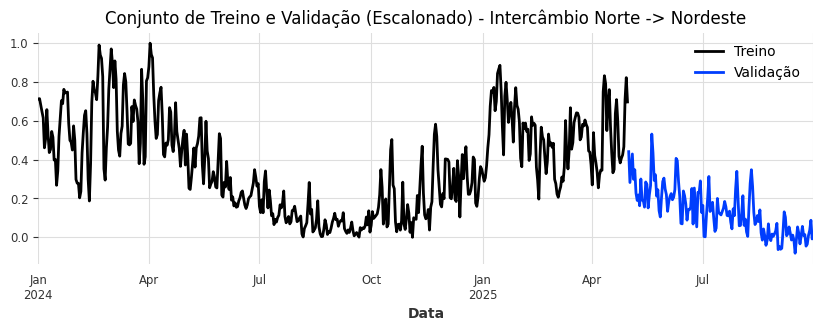

In [6]:
plt.figure(figsize=(10, 3))
train_scaled.plot(label="Treino")
val_scaled.plot(label="Validação")
plt.title('Conjunto de Treino e Validação (Escalonado) - Intercâmbio Norte -> Nordeste')
plt.xlabel('Data')
plt.legend()

## Construir modelo

In [8]:
model_name = "TFT_Intercambio_N_NE_Diario_2024_2025"
my_model = TFTModel(
    input_chunk_length=56, # 8 semanas
    output_chunk_length=28,  # 4 semanas
    n_epochs=30,
    dropout=0.2,
    batch_size=32, # valor padrão
    hidden_size=16, # valor padrão
    lstm_layers=4, # valor padrão (1)
    num_attention_heads=4, # valor sugerido pelo darts
    norm_type='LayerNorm',
    feed_forward='GatedResidualNetwork',
    add_relative_index=True,
    likelihood=None,
    loss_fn=MSELoss(),
    random_state=0,
)

## Treinar Modelo

In [9]:
my_model.fit(
    series=train_scaled,
    past_covariates=day_series,
    val_series=val_scaled,
    val_past_covariates=day_series,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | MSELoss                          | 0      | train
1  | train_criterion                   | MSELoss                          | 0      | train
2  | val_criterion                     | MSELoss                          | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection                 | 0      | train
5  | input_embeddings                  | _MultiEmbedding                  | 0      | train
6  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
7  | encoder_vsn                       | _VariableSelectionNetw

Epoch 29: 100%|████████████████████████████████████████████████████████████████████████████████| 13/13 [00:04<00:00,  3.02it/s, train_loss=0.0288, val_loss=0.012]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|████████████████████████████████████████████████████████████████████████████████| 13/13 [00:04<00:00,  3.02it/s, train_loss=0.0288, val_loss=0.012]


TFTModel(output_chunk_shift=0, hidden_size=16, lstm_layers=4, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, skip_interpolation=False, loss_fn=MSELoss(), likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=56, output_chunk_length=28, n_epochs=30, batch_size=32, random_state=0)

## Carregar Modelo

## Backtest

In [11]:
backtest = my_model.historical_forecasts(
    series=ts_scaled,
    past_covariates=day_series,
    start=val_scaled.start_time(),
    forecast_horizon=28, # 4 semanas
    stride=28, # 4 semanas
    last_points_only=False,
    retrain=False,
    verbose=True,
)
backtest = concatenate(backtest)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 18.95it/s]


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

NameError: name 'backtest' is not defined

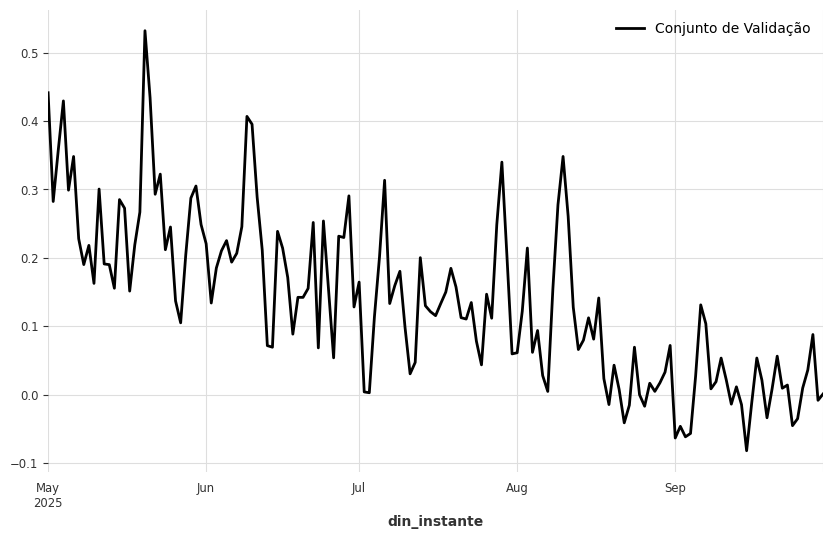

In [12]:
plt.figure(figsize=(10, 6))
val_scaled.plot(label="Conjunto de Validação")
backtest.plot(label="Backtest (H=28)")
plt.title('Backtest Com Horizonte de 4 Semanas - Intercâmbio Norte -> Nordeste')
plt.xlabel('Data')
plt.legend()

In [62]:
from darts.metrics import mae, mse

print(f"MAE: {mae(val_scaled,backtest)}")
print(f"MSE: {mse(val_scaled,backtest)}")

MAE: 0.12262279549161043
MSE: 0.021136252921159244


In [63]:
# dados de outubro
real = TimeSeries.from_dataframe(dataframe_n_ne_diario_compare, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="D")

# Previsão para o próximo mês (outubro de 2025)
pred_scaled = my_model.predict(
    n=28,
    series=ts,               # A partir de onde prever (fim do treino+validação)
    past_covariates=day_series # Covariáveis disponíveis (precisa conter os valores para o horizonte de previsão)
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                    | 0/? [00:00<…

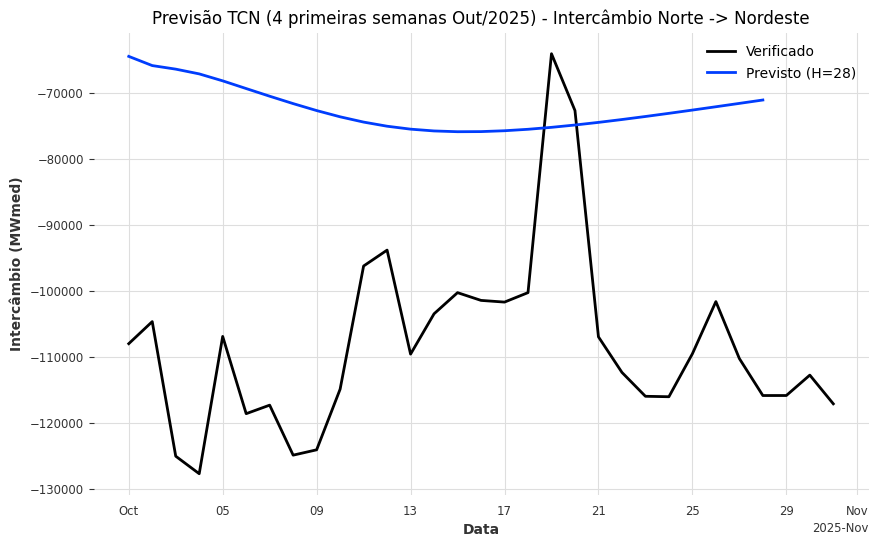

In [65]:
predicted = scaler.inverse_transform(pred_scaled)

plt.figure(figsize=(10, 6))
real.plot(label="Verificado")
predicted.plot(label="Previsto (H=28)")
plt.title('Previsão TCN (4 primeiras semanas Out/2025) - Intercâmbio Norte -> Nordeste')
plt.ylabel('Intercâmbio (MWmed)')
plt.xlabel('Data')
plt.legend()

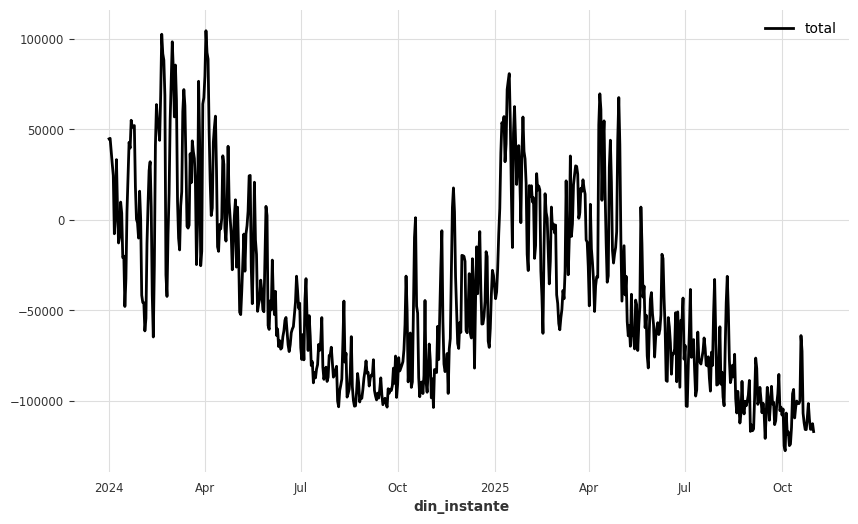

In [14]:
total = TimeSeries.from_dataframe(dataframe_n_ne_diario, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="D")

plt.figure(figsize=(10, 6))
total.plot(label="total")
plt.legend()